In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import math 
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

def make_timedelta(df, col):
    df['seconds'] = df[col]
    df[col] = pd.to_timedelta(df[col], unit='s')

In [236]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Benchmark of 10Mb reference vs 10Mb query

In [237]:
min_len = 50
window_size = 20
ref_size = "10Mb_equal"

In [238]:
def get_runtime_df(filename):
    df = pd.read_csv(filename, sep = "\t")
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)

    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([9, 13, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)

    to_remove = []
    for col in more.columns:
        #print(col)
        #print(more[col])
        if (len(np.unique(more[col])) == 1):
            to_remove.append(col)

    to_remove.append(14)
    more.drop(to_remove, axis = 1, inplace = True)

    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df


In [346]:
def get_seg_len_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 8, 9, 10, 13, 14, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df

def get_no_time_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    #print(len(more[col].iloc[0].split('_')))
    if (len(more[col].iloc[0].split('_')) == 3):
        more[["rep", "e", "bins", "end"]] = more[col].str.split('_',expand=True)
        more.drop(["e", "end", "index"], axis = 1, inplace = True)
    else:
        print(len(more[col].iloc[0].split('_')))
        more[["rep", "e", "bins"]] = more[col].str.split('_',expand=True)
        more.drop(["e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df



In [240]:
1048610 / 3495

300.0314735336195

build executable reads all sequences to memory

build_io executable fetches sequences on demand

In [299]:
df = get_no_time_df(ref_size + "/full.log")
build = df[df["exec-path"] == "build"].copy()

#build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
#io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

3


In [300]:
np.unique(build["threads"])

array([1, 4])

In [301]:
np.unique(build["seg-count"])

array([  10,   20,   50,  250,  500, 1000, 2000, 4000, 8000], dtype=int32)

In [302]:
np.unique(build["bins"])

array([  64,  128,  256,  512, 1024, 2048, 4096, 8192], dtype=int32)

#### Threads

In [303]:
#data = build[build["max-queued-carts"] == 1000]
#data = data[data["adapt_cutoff"] == 0.5]

data = build[build["threads"] == 1].copy()
#data = data[data["seg-count"] == 4000]
#data = data[data["cart-max-capacity"] > 1]

In [ ]:
# databases * 2 due to forward and reverse
ibf_size = 17508570
database_size = 10 * 1024 * 1024
query_size = 10 *1024 * 1024

data["memory-model"] = (data["Memory (kb)"] * 1000 - (ibf_size + 2 * database_size + 2 * query_size)).astype(int)

seg_len = query_size / data["seg-count"].iloc[0] + min_len
qgram_size = 12
kmers_per_segment = int(seg_len - qgram_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 32
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)

#data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1000), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round(data["memory-model"] / (data["Memory (kb)"] * 1000) * 100, 2)
data

In [ ]:
#data = io[io["max-queued-carts"] == 1000]
#data = data[data["cart-max-capacity"] == 1000]
#data = data[data["seg-count"] == 3495]
#data = data[data["adapt_cutoff"] == 0.5]

data = io[io["threads"] == 1].copy()
data

#### Error rate test

In [248]:
ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "error_rate_test"
bins = [1024, 64, 128, 256, 512, 1024, 2048, 4096] # only for e = 0.06 otherwise always 1024
b = 1024
print("bin-cutoff\terror-rate\tbins\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
for er in [0.02, 0.04, 0.06, 0.08, 0.1]:
    frames = []
    for rep in range(1, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_seg_len_df(ref_size + "/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]

        if (er == 0.06):
            acc["bins"] = bins
            df["bins"] = bins
        else:
            acc["bins"] = [1024]
            df["bins"] = [1024]
            
        ref_len = 100 * 1024 * 1024
        df = pd.merge(df, acc, on = ["bins", "adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        df = df[df["bins"] == 1024]
        frames.append(df)
    data = pd.concat(frames)
        
    print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(b) + "\t" +
        str(data[data["bins"]==b].iloc[0]["seg-len"]) + "\t" + 
            str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 2)) + "\t" +  
                str(int(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]), 2))) + "\t" +
                        str(np.round(np.mean(data[data["bins"]==b]["missed"]), 2)))

bin-cutoff	error-rate	bins	seg-len	mean time (s)	mean memory (kb)	missed


FileNotFoundError: [Errno 2] No such file or directory: '10Mb_equal/error_rate_test/search_efficiency_rep1_e0.02.log'

#### Cart parameters

In [347]:
ref_size = "10Mb_equal"
df = get_no_time_df(ref_size + "/full.log")
build = df[df["exec-path"] == "build"].copy()

#build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
#io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

colors = [CB_color_cycle[4], CB_color_cycle[7]]

In [316]:
#ref_size = "10Mb_equal"
#df = get_no_time_df(ref_size + "/cart_params_test/full_params.log")
#df.head()

In [348]:
df_all = df.copy()
df = df[df["seg-count"]==4000]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"]==1000]
df = df[df["bins"] == 1024]
df.drop(["rep"], axis = 1, inplace = True)

df_cart = df.copy()
df

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads,bins
2,32.56,137256,0.5,3.0,build_io,4000,1000,1000,0.06,1,1024
3,158.40,58488,0.5,3.0,build_io,4000,10,1000,0.06,1,1024
4,33.41,78360,0.5,3.0,build_io,4000,100,1000,0.06,1,1024
5,33.07,118476,0.5,3.0,build_io,4000,1000,1000,0.06,1,1024
8,8.57,360600,0.5,3.0,build_io,4000,1000,1000,0.06,4,1024
...,...,...,...,...,...,...,...,...,...,...,...
309,6.30,332444,0.5,3.0,build,4000,1000,1000,0.06,4,1024
317,6.43,323952,0.5,3.0,build,4000,1000,1000,0.06,4,1024
325,6.00,311436,0.5,3.0,build,4000,1000,1000,0.06,4,1024
333,6.01,333596,0.5,3.0,build,4000,1000,1000,0.06,4,1024


In [349]:
build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

In [350]:
data = build.copy()
data["memory-model"] = (data["Memory (kb)"] * 1000 - (ibf_size + 2 * database_size + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 8
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1000), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1000)) * 100, 2)
data.head()

kmers_per_segment	2652


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,bins,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
62,25.18,141048,1000,1000,1,1024,70388683,21216000,0.15,49.90
63,21.83,72356,10,1000,1,1024,22700523,212160,0.00,31.37
64,17.98,91112,100,1000,1,1024,39547083,2121600,0.02,43.40
65,23.66,204516,1000,1000,1,1024,133856683,21216000,0.10,65.45
68,6.11,332068,1000,1000,4,1024,197760683,84864000,0.26,59.55


In [351]:
kmers_per_segment = int(seg_len - qgram_size + 1)
kmers_per_segment

2660

In [352]:
def plot_cols(data, ax, column, color, label):
    capacities = [1, 2, 4, 1000]
    data_list = []
    for c in capacities:
        data_list.append(data[data["max-queued-carts"]==c][column])
        
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=capacities)  # will be used to label x-ticks

    # fill with colors
    local_colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], local_colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])

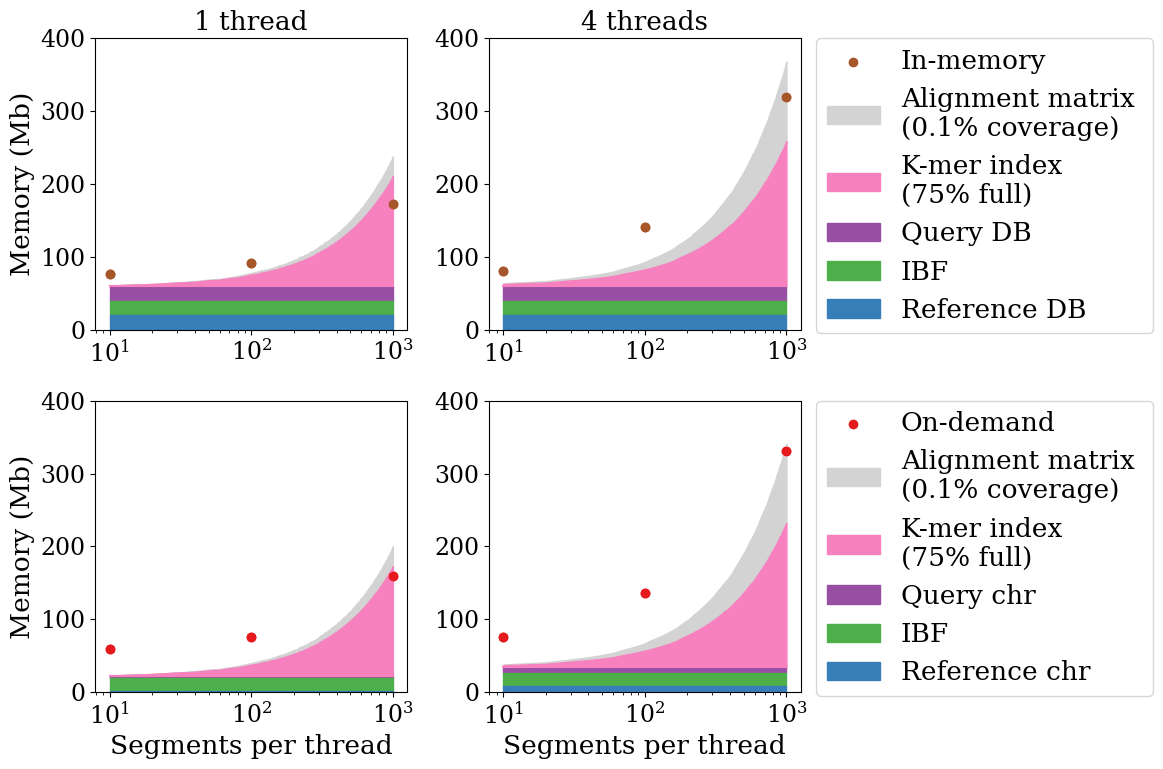

In [353]:
ibf_size = 17944233 + 41414 + 390
database_size = 10 * 1024 * 1024
query_size = 10 * 1024 * 1024

qindex_full = 0.75
qgram_size = 12
bytes_per_qgram = 16 # assuming no repeat k-mers

window_size = 20
bytes_per_window = 1

query_seg_count = 4000
query_segment_size = int(round(query_size / query_seg_count, 0)) 

queue_capacity = 50
hit_coverage = 0.001

styles = ["-", "-"]
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12, 8)

labels = ["In-memory", "On-demand"]

mem_labels = ["K-mer index\n(" + str(int(round(100 * qindex_full))) +"% full)", "Query DB", "Query chr", "IBF", "Reference DB", "Reference chr", "Alignment matrix \n(" + str(round(100 * hit_coverage, 1)) + "% coverage)", "Local filter"]
i = 0
j = 0

column = "Time (s)"

#x_values = range(10 * query_segment_size, 1010 * query_segment_size, 10 * query_segment_size)
x_values = range(10, 1010, 10)
size_correction = np.array([x * math.log(10, x) for x in x_values])
#size_correction = x_values
#print(size_correction) 
for t in [1, 4]:    
    queue_capacity = int(round(1/t * queue_capacity))
    data = build.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    #data["cart-size"] = data["cart-max-capacity"] * query_segment_size
    #data = data.groupby('cart-size').agg('mean')
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len
    
    databases = [int(np.round(2 * database_size / 10**6, 0))] * x_len
    ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
    queries = [int(np.round((2 * query_size) / 10**6 + ibf[0], 0))] * x_len
    
    bin_size = database_size / 1024
    
    seg_len = query_size / df["seg-count"].iloc[0] + min_len
    kmers_per_segment = int(seg_len - qgram_size + 1)

    x_len = len(x_values)
    local_filter_size = [queries[0]] * x_len
    
    fullness = (1 + 1 - qindex_full) * bytes_per_qgram
    seqan2_seq_size = queue_capacity * seg_len * x_values * t / 10**6 
    #print(seqan2_seq_size)
    kmer_index_size = (t * size_correction * kmers_per_segment * fullness / 10**6 + seqan2_seq_size + queries[0]).astype(int)

    kmers_per_segment = int(seg_len - window_size + 1)

    alignment_matrix_size = (np.array(x_values) * t * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    
    aks = ax[i][j]
    aks.semilogx(x_values, local_filter_size, color = CB_color_cycle[3])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, label = labels[i], color = colors[i])
    #aks.fill_between(x_values, kmer_index_size, data["Memory (kb)"] / 1000, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, local_filter_size, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, data["local-filter-size"], label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(data.index.values, ibf, queries, label = mem_labels[1], color = CB_color_cycle[5])
    aks.fill_between(data.index.values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(data.index.values, zeroes, databases, label = mem_labels[4], color = CB_color_cycle[0])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, color = colors[i])
    
    i = 1

    aks = ax[i][j]
    
    data = io.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    #data["cart-size"] = data["cart-max-capacity"] * query_segment_size
    #data = data.groupby('cart-size').agg('mean')
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len

    database_chr_size = database_size / 10
    query_chr_size = query_size / 10
    
    databases = [int(np.round(t * 2 * database_chr_size / 10**6, 0))] * x_len
    ibf = [int(np.round(ibf_size / 10**6 + databases[0], 0))] * x_len
    queries = [int(np.round(t * 2 * query_chr_size / 10**6 + ibf[0], 0))] * x_len

    
    x_len = len(x_values)

    local_filter_size = [queries[0]] * x_len
    
    fullness = (1 + 1 - qindex_full) * bytes_per_qgram 
    seqan2_seq_size = queue_capacity * seg_len * x_values * t / 10**6 
    #print(seqan2_seq_size)
    kmer_index_size = (t * size_correction * kmers_per_segment * fullness / 10**6 + seqan2_seq_size + queries[0]).astype(int)

    kmers_per_segment = int(seg_len - window_size + 1)
    
    #alignment_matrix_size = (data["threads"].iloc[0] * x_values * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    alignment_matrix_size = (np.array(x_values) * t * hit_coverage * seg_len * bin_size / 10**6 + kmer_index_size).astype(int)
    #print(alignment_matrix_size)
    aks.semilogx(x_values, local_filter_size, color = CB_color_cycle[3])

    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, label = labels[i], color = colors[i])
    aks.fill_between(x_values, kmer_index_size, alignment_matrix_size, label = mem_labels[6], color = "lightgray")
    #aks.fill_between(data.index.values, data["kmer-index-size"], data["Memory (kb)"] / 10**3, label = mem_labels[6], color = "lightgray")
    aks.fill_between(x_values, local_filter_size, kmer_index_size, label = mem_labels[0], color = CB_color_cycle[3])
    #aks.fill_between(data.index.values, queries, , label = mem_labels[7], color = CB_color_cycle[6])
    aks.fill_between(data.index.values, ibf, queries, label = mem_labels[2], color = CB_color_cycle[5])
    aks.fill_between(data.index.values, databases, ibf, label = mem_labels[3], color = CB_color_cycle[2])
    aks.fill_between(data.index.values, zeroes, databases, label = mem_labels[5], color = CB_color_cycle[0])
    aks.scatter(data.index.values, data["Memory (kb)"] / 10**3, color = colors[i])
    
    i = 0
    j += 1

for i in range(0, 2, 1):
    for j in range(0, 2, 1):
        ax[i][j].set_ylim(0, 400)
        #ax[i][j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
        #ax[i][j].set_xlabel("Cart capacity")
    
i = 1
for j in range(0, 2, 1):
    ax[i][j].set_xlabel("Segments per thread")
j = 0
for i in range(0, 2, 1):
    ax[i][j].set_ylabel("Memory (Mb)")

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor = (1.05, 1),  loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_memory_usage.png", dpi=400, bbox_inches='tight')
plt.show()

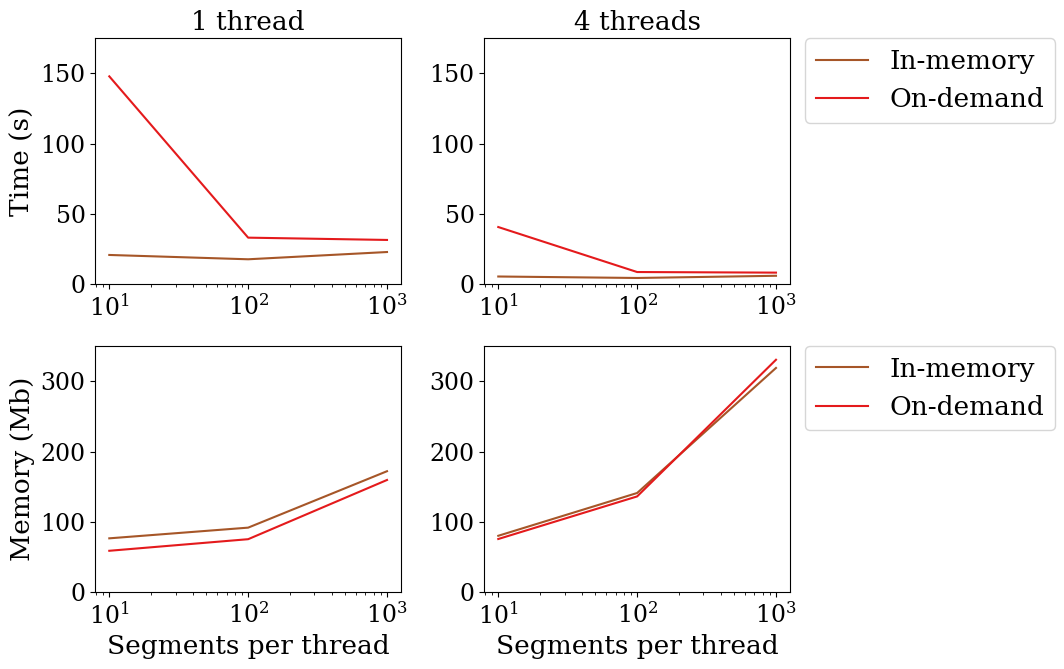

In [354]:
ref_size = "10Mb_equal"
if (ref_size == "10Mb_equal"):
    df = df_cart.copy()
    df = df[df["bins"] == 1024]

df = df[df["seg-count"]==4000]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"] == 1000]

build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

fig, ax = plt.subplots(2, 2)
#fig.set_figheight(8)
fig.set_size_inches(11, 7)

labels = ["In-memory", "On-demand"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].semilogx(data.index.values, data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[1][j].set_ylim(0, 350)
        ax[0][j].set_ylim(0, 175)
        ax[1][j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
        #ax[1][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Segments per thread")
        i+=1
    j += 1

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

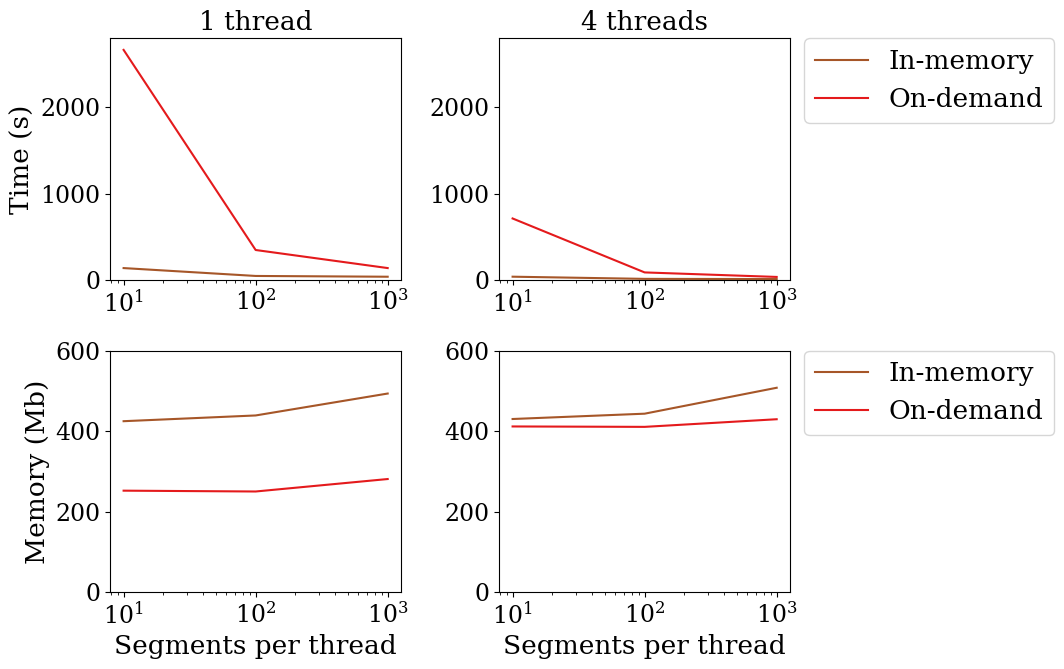

In [355]:
def get_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "index", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "index"
    more[col] = more[col].str.removeprefix("index /dev/shm/markov/" + ref_size + "/")
    more[col] = more[col].str.removesuffix(".index ")

    more[["rep", "e", "bins"]] = more[col].str.split('_',expand=True)
    more.drop(["e", "index"], axis = 1, inplace = True)
    
    col = "rep"
    more[col] = more[col].str.removeprefix(col)
    col = "bins"
    more[col] = more[col].str.removeprefix("b")
    
    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.dropna()
    df = df[df["rep"] != "seg"]
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float', "bins" : 'int32'})
    return df

ref_size = "100Mb"
df = get_df(ref_size + "/cart_params_test/full.log")
df = df[df["seg-count"]>3400]
df = df[df["error-rate"]==0.06]
df = df[df["max-queued-carts"] == 1000]
#df["cart-max-capacity"] = df["cart-max-capacity"] * 300 
df.drop(["rep"], inplace = True, axis = 1)

build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

fig, ax = plt.subplots(2, 2)
#fig.set_figheight(8)
fig.set_size_inches(11, 7)

labels = ["In-memory", "On-demand"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].semilogx(data.index.values, data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [build, io]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].set_ylim(0, 2800)
        ax[1][j].set_ylim(0, 600)
        ax[1][j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
        #ax[1][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Segments per thread")
        i+=1
    j += 1

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

In [356]:
ref_size = "10Mb_equal"
df = get_no_time_df(ref_size + "/full.log")
np.unique(df["max-queued-carts"])

array([  10,  100, 1000], dtype=int32)

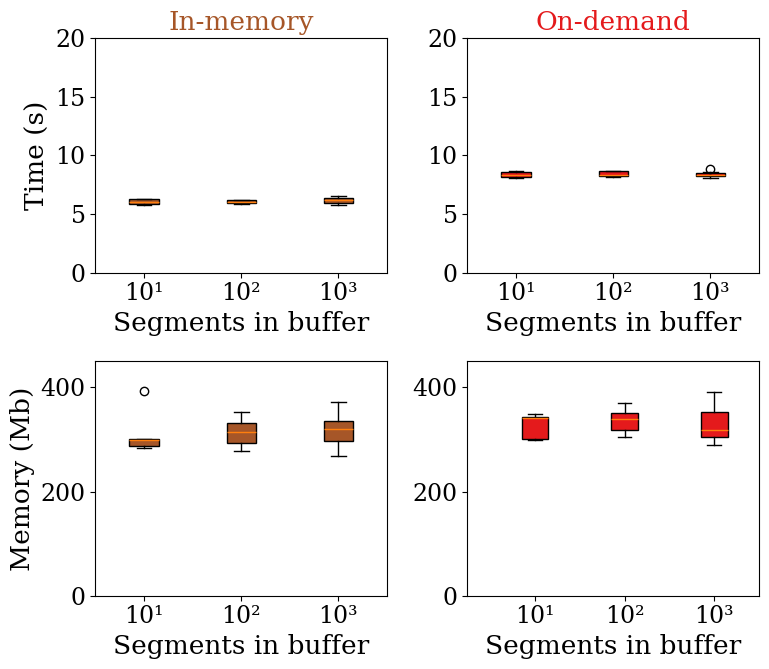

In [358]:
fig, ax = plt.subplots(2, 2, sharey = False)
fig.set_size_inches(8, 7)

#i = 0
data = df_cart.copy()

i = 1

if (i==1):
    df = df[df["seg-count"]==4000]
    df = df[df["error-rate"]==0.06]
    df = df[df["cart-max-capacity"] == 1000]
    #df = df[df["cart-max-capacity"] > 1]
    df = df[df["bins"] == 1024]
    data = df

df_copy = data.copy()

x_cols = ["cart-max-capacity", "max-queued-carts"]
x_col = x_cols[i]

#TODO: how many Mb per 10¹?
colnames = ["Segments per thread", "Segments in buffer"]
colname = colnames[i]

def plot_cols(data, ax, column, color, label):
    
    labels = [r"10¹", r"10²", r"10³"]
    capacities = [10, 100, 1000]
    
    data_list = []
    for c in capacities:
        data_list.append(data[data[x_col]==c][column])
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=labels)  # will be used to label x-ticks

    # fill with colors
    local_colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], local_colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])

for t in [4]:
    data = data[data["threads"] == t]
    data = data[data[x_cols[not(i)]] == 1000]
    col = x_cols[i]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Time (s)"
    plot_cols(io, ax[0][1], col, colors[1], "On-demand")
    plot_cols(build, ax[0][0], col, colors[0], "In-memory")

    ax[0][0].set_title("In-memory", color = colors[0])
    ax[0][1].set_title("On-demand", color = colors[1])
    ax[0][0].set_xlabel(colname)
    ax[0][1].set_xlabel(colname)
    ax[0][0].set_ylabel("Time (s)")
    ax[0][0].set_ylim(0, 50)
    ax[0][1].set_ylim(0, 50)
    if (i==1):
        ax[0][0].set_ylim(0, 20)
        ax[0][1].set_ylim(0, 20)
    
    #ax[0].plot(data[col], data["Time (s)"], linestyle = "dotted", color = colors[i])

    data = df_copy.copy()
    data = data[data["threads"] == t]
    data = data[data[x_cols[not(i)]] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Memory (kb)"
    io[col] = io[col] / 1000
    build[col] = build[col] / 1000
    plot_cols(io, ax[1][1], col, colors[1], "On-demand")
    plot_cols(build, ax[1][0], col, colors[0], "In-memory")

    ax[1][0].set_ylabel("Memory (Mb)")
    #ax[1][1].set_ylabel("Memory (Mb)")

    ax[1][0].set_xlabel(colname)
    ax[1][1].set_xlabel(colname)
    ax[1][0].set_ylim(0, 450)
    ax[1][1].set_ylim(0, 450)

    ax[1][1].plot(0.4, 0.4, linestyle = "-.", color = colors[0], label = "In-memory")
    ax[1][1].plot(0.4, 400, color = colors[1], label = "On-demand")

    #ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #fig.suptitle("Searching 10k matches between \n100Mb reference and 1Mb query\n using " + str(t) + " threads")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_" + x_col + "_t" + str(t) + ".png", dpi=400, bbox_inches='tight')
    plt.show()

#### Segment length

In [ ]:
# bash remove_dist_stellar.sh
ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "seg_len_test"

dataframes = []
for er in [0.06, 0.08, 0.1]:
    frames = []
    for rep in range(1, 6, 1):    
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_no_time_df(ref_size + "/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        
        #print(df)
        acc = pd.read_csv(ref_size + "/" + dir_name + "/read_all/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        #print(acc)
        df["adapt_cutoff"] = df["adapt_cutoff"].astype(float)
        df = df[df["adapt_cutoff"] == bin_cutoff]
        #print(df)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["seg-count"] = [10, 20, 50, 250, 500, 1000, 2000, 4000, 8000] * 2
        #print(acc)
        query_len = 1024 * 1024
        df["seg-len"] = (query_len / df["seg-count"]).astype(int)
        df = pd.merge(df, acc, on = ["seg-count", "adapt_cutoff"], how = "inner")
        frames.append(df)
    data = pd.concat(frames)
    dataframes.append(data)

    print("bin-cutoff\terror-rate\tseg-count\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for seg_count in [8000, 4000, 2000, 1000, 500, 250, 50, 20, 10]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(seg_count) + "\t" +
            str(data[data["seg-count"]==seg_count].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["seg-count"]==seg_count]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["seg-count"]==seg_count]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["seg-count"]==seg_count]["missed"]), 2)))

In [ ]:
d = dataframes[0][["seg-count", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('seg-count').agg('mean')
d["seg-len"] = d["seg-len"] * 1000000 / 1024 / 1024 + 1
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1000).astype(int)
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d

#### Bin count

In [ ]:
# bash remove_dist_stellar.sh
ref_size = "10Mb_equal"
bin_cutoff = 0.5
dir_name = "bin_count_test"
bins = [1024, 64, 128, 256, 512, 1024, 2048, 4096]
for er in [0.06]:
    frames = []
    for rep in range(1, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_no_time_df(ref_size + "/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/" + dir_name + "/read_all/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["bins"] = bins
        df["bins"] = bins
        ref_len = 100 * 1024 * 1024
        df = pd.merge(df, acc, on = ["bins", "adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        frames.append(df)
    data = pd.concat(frames)
        
    print("bin-cutoff\terror-rate\tbins\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for b in bins[1:]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(b) + "\t" +
            str(data[data["bins"]==b].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["bins"]==b]["missed"]), 2)))

In [ ]:
d = data[["bins", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('bins').agg('mean')
d["seg-len"] = d["seg-len"] * 1000000 / 1024 / 1024 + 1
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1024).astype(int)
#make_timedelta(d, "Time (s)")
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d